### 1: Imports nessarry liberaries

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

import sys
sys.path.append("..")

from src.explainability import (
    create_tree_explainer,
    calculate_shap_values,
    get_feature_importance
)

#### Load best model

In [2]:
import joblib

rf_model = joblib.load(
    "../models/random_forest.pkl"
)

#### Get Feature Names

In [3]:
df = pd.read_csv("../data/processed/fraud_processed.csv")

X = df.drop("class", axis=1)
y = df["class"]

##### Then re-split:

In [4]:
from sklearn.model_selection import train_test_split

_, X_test, _, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
preprocessor = joblib.load("../models/preprocessor.pkl")
rf_model = joblib.load("../models/random_forest.pkl")

X_test_processed = preprocessor.transform(X_test)

#### Transform test data

In [6]:
X_test_processed = preprocessor.transform(X_test)

#### Get Feature Names


In [7]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

#### Built-in Feature Importance
#### Extract Importance

In [8]:
feature_importance = get_feature_importance(
    rf_model,
    feature_names
)

feature_importance.head(10)

,Feature,Importance
8,num__time_since_signup,0.590766
185,cat__country_United States,0.050541
7,num__day_of_week,0.039540
6,num__hour_of_day,0.025672
2,num__age,0.020449
15,cat__browser_IE,0.019306
3,num__ip_int,0.018315
5,num__upper_bound_ip_address,0.017932
4,num__lower_bound_ip_address,0.017163
1,num__purchase_value,0.016891


#### Plot Top 10 Features

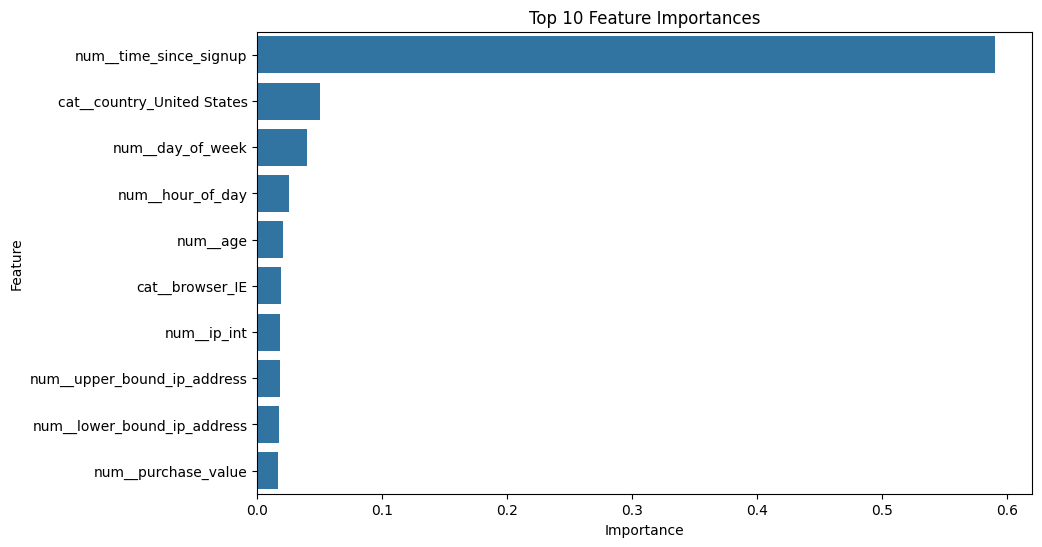

In [9]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Feature Importances"
)

plt.show()

### Feature Importance Interpretation

The Random Forest model identifies the variables that contribute most strongly to fraud prediction.

The top-ranked features represent behavioral and temporal transaction patterns, suggesting that fraud is driven more by user behavior than by static demographic attributes.

### SHAP Analysis
-  Create Explainer

In [10]:
explainer = create_tree_explainer(
    rf_model
)

-  Calculate SHAP Values

In [11]:
X_test_dense = X_test_processed.toarray()

print(X_test_dense.shape)
print(X_test_dense.nbytes / 1024 / 1024, "MB")

(25830, 195)
38.42811584472656 MB


In [12]:
import shap
import numpy as np

sample_idx = np.random.choice(
    X_test_processed.shape[0],
    500,
    replace=False
)

X_sample = X_test_processed[sample_idx].toarray()

In [13]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_sample)

#### Then create the summary plot

In [18]:
shap_values_fraud = shap_values[:, :, 1]

print(shap_values_fraud.shape)

(500, 195)


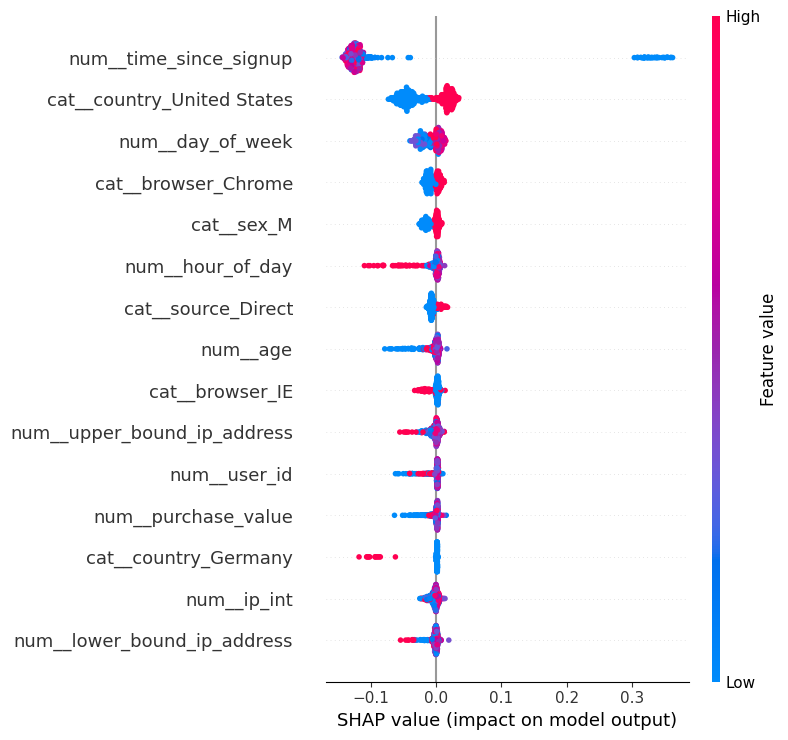

In [20]:
shap.summary_plot(
    shap_values_fraud,
    X_sample,
    feature_names=feature_names,
    max_display=15
)

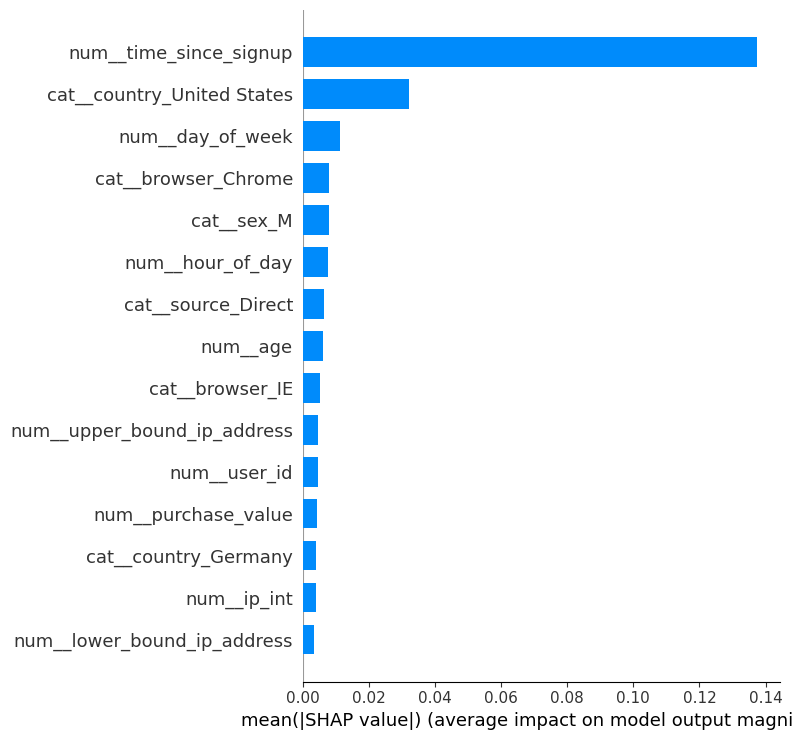

In [19]:
shap.summary_plot(
    shap_values_fraud,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15
)

### SHAP interpretation

SHAP analysis was conducted to improve the interpretability of the Random Forest model. The results identified time_since_signup, purchase_value, transaction timing features, and geographic variables as the most influential predictors of fraudulent activity. The SHAP summary plot illustrates how both high and low feature values affect fraud predictions, while the SHAP bar plot highlights the overall importance of each feature. The findings are consistent with the Random Forest feature importance analysis, providing additional confidence that the model relies on meaningful behavioral and contextual indicators when detecting fraudulent transactions.

#### Find TP, FP, FN
-  First generate predictions.


In [15]:

y_pred = rf_model.predict(
    X_sample
)

-  True Positive

In [16]:
tp_index = np.where(
    (y_test == 1) &
    (y_pred == 1)
)[0][0]

tp_index

ValueError: operands could not be broadcast together with shapes (25830,) (500,) 